In [1]:
!pip install pdfminer.six

In [2]:
import pdfminer
from pdfminer.high_level import extract_pages
from pdfminer.layout import LTTextBox
import pandas as pd
import numpy as np

In [3]:
import os

pdf_files = [f for f in os.listdir('.') if f.endswith('.pdf')]

if pdf_files:
    pdf_path = pdf_files[0]
    print(f"Используется PDF-файл: {pdf_path}")
else:
    raise Exception("PDF-файлы не найдены в текущем каталоге")

Используется PDF-файл: dasc2017.pdf


In [4]:
class PDF_to_text_extractor():
  def __init__(self, file_path:str|None = None):
    self.pdf_path = None
    self.text_content = None
    self.boxes = []
    if file_path:
      self.pdf_path = file_path
      # self.text_content = extract_pages(file_path)
    else: print("Файл отсутствует или указан неверный путь.")

  def extract_text_from_boxes(self) -> None:
    try:
        for page_layout in extract_pages(self.pdf_path):
            for element in page_layout:
                if isinstance(element, LTTextBox):
                    # print(f"--- Box at {element.bbox} ---")
                    self.boxes.append([element.bbox, element.get_text().strip()])
    except Exception as e:
        print(f"Ошибка при обработке файла: {e}")

  def _get_text_rects(self):
    pass

In [5]:
document = PDF_to_text_extractor(pdf_path)
document.extract_text_from_boxes()

In [6]:
def collect_pdf_data(doc:PDF_to_text_extractor):
    data = []
    for page_layout in extract_pages(pdf_path):
        page_width = page_layout.width
        page_height = page_layout.height
        for element in page_layout:
            if isinstance(element, LTTextBox):
                text = element.get_text().strip()
                if not text: continue

                # Извлекаем признаки (features)
                x0, y0, x1, y1 = element.bbox
                data.append({
                    'text': text,
                    'len': len(text),
                    'x0': x0 / page_width,  # Нормализация
                    'y0': y0 / page_height,
                    'x1': x1 / page_width,
                    'y1': y1 / page_height,
                    'num_lines': text.count('\n') + 1,
                    'is_article': 1 # Временная метка для обучения
                })
    return pd.DataFrame(data)

df_features = collect_pdf_data(pdf_path)
display(df_features.head())

,text,len,x0,y0,x1,y1,num_lines,is_article
0,"See discussions, stats, and author profiles fo...",119,0.065147,0.898938,0.549211,0.906489,1,1
1,A machine learning approach for prediction of ...,75,0.065147,0.858014,0.908606,0.874794,1,1
2,Conference Paper · September 2017,33,0.065147,0.828978,0.228756,0.837463,1,1
3,DOI: 10.1109/DASC.2017.8102138,30,0.065147,0.817359,0.169894,0.823232,1,1
4,CITATIONS\n62,12,0.065147,0.761213,0.104022,0.782638,2,1


In [7]:
# # Автоматическая разметка блоков на основе эвристик для быстрого улучшения
# for i in range(len(df_features)):
#     row = df_features.iloc[i]
#     # Эвристика: короткий текст или текст в самом низу/верху часто является оформлением
#     if row['len'] < 50 or row['y0'] < 0.2 or row['y1'] > 0.8:
#         df_features.at[i, 'is_article'] = 0
#     else:
#         df_features.at[i, 'is_article'] = 1

# # Подготовка данных
# X_updated_heur = df_features[:][features].values
# y_updated_heur = df_features[:]['is_article'].values

# print(f"Обновлено меток: {len(y_updated_heur)}")
# print(f"Распределение классов: {np.bincount(y_updated_heur.astype(int))}")

In [8]:
import tensorflow as tf
from tensorflow.keras import layers

def build_classifier_model(input_shape):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid') # Бинарная классификация
    ])

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("Архитектура модели готова. Метки: 0 - оформление, 1 - текст статьи")

Архитектура модели готова. Метки: 0 - оформление, 1 - текст статьи


In [9]:
training_data = pd.read_csv('compiled.csv')

# 2. Подготовка признаков (X) и целевой переменной (y)
features = ['len', 'x0', 'y0', 'x1', 'y1', 'num_lines']
X_train = training_data[features].values
y_train = training_data['is_article'].values

print(f"Загружено строк для обучения: {len(training_data)}")

# Cоздание и обучение модели
input_dim = X_train.shape[1]
model = build_classifier_model(input_dim)

print("Начало обучения на загруженном датасете...")
history = model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

print(f"Обучение завершено. Финальная точность: {history.history['accuracy'][-1]:.4f}")

Загружено строк для обучения: 798
Начало обучения на загруженном датасете...
Обучение завершено. Финальная точность: 0.8772


In [10]:
# input_dim = X.shape[1]
# # Обучение модели на вручную размеченных данных
# model = build_classifier_model(input_dim)
# history = model.fit(X_updated_heur, y_updated_heur, epochs=20, verbose=0)

# # Предсказание для всего документа
# predictions = model.predict(X)
# df_features['is_article_prob'] = predictions
# df_features['predicted_class'] = (predictions > 0.5).astype(int)

# # Проверка результата
# article_blocks_new = df_features[df_features['predicted_class'] == 1]
# print(f"После дообучения найдено блоков статьи: {len(article_blocks_new)} из {len(df_features)}")
# display(article_blocks_new[['text', 'is_article_prob']].head(10))

In [12]:
# Предсказание вероятностей
X = df_features[['len', 'x0', 'y0', 'x1', 'y1', 'num_lines']].values
predictions = model.predict(X)

threshold = 0.5
df_features['is_article_prob'] = predictions
df_features['predicted_class'] = (predictions > threshold).astype(int)

# Вывод только тех блоков, которые классифицированы как текст статьи
article_blocks = df_features[df_features['predicted_class'] == 1]
print(f"Найдено блоков текста статьи: {len(article_blocks)} из {len(df_features)}")
display(article_blocks[['text', 'is_article_prob']].head(10))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Найдено блоков текста статьи: 28 из 159


,text,is_article_prob
18,"Balasubramanian Thiagarajanα, Lakshminarasimha...",0.575398
19,Abstract—One of the major business problems th...,0.987727
24,reported an average on-time arrival rate of 76...,0.943288
25,"rier, extreme weather, National Aviation Syste...",0.774435
26,"In our paper, a two-stage predictive model was...",0.989950
32,A statistical method has been deployed by Muel...,0.599947
33,Xu et al. [5] in their paper have developed a ...,0.816453
34,Rebollo and Balakrishnan [9] proposed a new cl...,0.781358
35,"In the existing literature, researchers have w...",0.786411
40,On-time performance data was sourced from a da...,0.992156


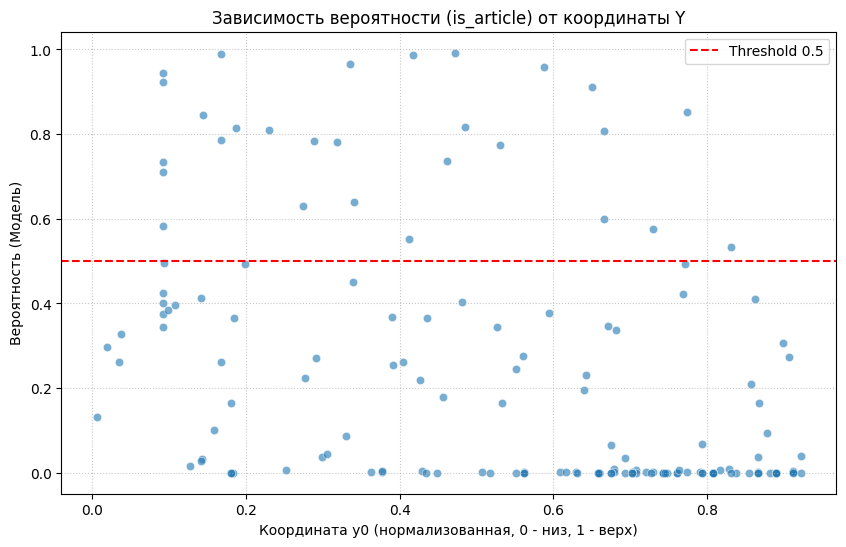

In [13]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# plt.figure(figsize=(10, 6))
# sns.scatterplot(data=df_features, x='y0', y='is_article_prob', alpha=0.6)
# plt.axhline(y=0.5, color='r', linestyle='--', label='Threshold 0.5')
# plt.title('Зависимость вероятности (is_article) от координаты Y')
# plt.xlabel('Координата y0 (нормализованная, 0 - низ, 1 - верх)')
# plt.ylabel('Вероятность (Модель)')
# plt.grid(True, linestyle=':', alpha=0.7)
# plt.legend()
# plt.show()

In [15]:
full_text = "\n\n".join(article_blocks['text'].tolist())

file_name = "article_content.txt"
with open(file_name, "w", encoding="utf-8") as f:
    f.write(full_text)

print(f"Текст сохранен в файл: {file_name}")
print(f"Общая длина текста: {len(full_text)} символов.")

Текст сохранен в файл: article_content.txt
Общая длина текста: 20599 символов.


In [16]:
df_features.to_csv('training_dataset.csv', index=False)
print("Датасет сохранен в 'training_dataset.csv'")

Датасет сохранен в 'training_dataset.csv'
